The AB test is a randomized experiment that is used by most large companies to evaluate the launch of new functionality. Various difficulties may arise in the analysis and conduct of the experiment. Several typical problematic cases from real life are given in this dataset and analysis.

### Content
1. [Loading and processing data](#Loading)
2. [Statistical Analysis](#Statistical)
3. [Conclusions](#Conclusions)

### Loading and processing data <a name="Loading"/>

Let's import the necessary libraries and load the data

In [40]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import shapiro

In [41]:
# TODO : import the dataset
df = pd.read_csv('AB_Test_Results.csv')
data = df.copy()

In [42]:
# TODO : take a quick look at the data
data.head(15)

,USER_ID,VARIANT_NAME,REVENUE
0,737,variant,0.00
1,2423,control,0.00
2,9411,control,0.00
3,7311,control,0.00
4,6174,variant,0.00
5,2380,variant,0.00
6,2849,control,0.00
7,9168,control,0.00
8,6205,variant,0.00
9,7548,control,0.00


In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   USER_ID       10000 non-null  int64  
 1   VARIANT_NAME  10000 non-null  object 
 2   REVENUE       10000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 234.5+ KB


Let's see if there are users who have two A/B test groups

In [44]:
# TODO : Look at the distribution of the number of unique groups for each user
unique_groups_per_user = df.groupby('USER_ID')['VARIANT_NAME'].nunique()
print(unique_groups_per_user.value_counts())


VARIANT_NAME
1    4783
2    1541
Name: count, dtype: int64


# **4783 users are in only one A/B Test group, and 1541 users are in 2 A/B test groups (these 1541 is an issue, users should be in only one group**

In [45]:
# TODO : Look at the distribution of the number of unique groups for each user in relative terms
unique_groups_per_user_relative = df.groupby('USER_ID')['VARIANT_NAME'].nunique().value_counts(normalize=True)
print(unique_groups_per_user_relative)


VARIANT_NAME
1    0.756325
2    0.243675
Name: proportion, dtype: float64


# **Approximately 75.63% of the users were in only one A/B test group. Approximately 24.36% of the users were in two A/B test groups. A significant portion (24.36%) of the data is potentially compromised.**

What can you observe ? Should we exclude these users ? Why ?

In [46]:
# TODO : users have 1 A/B test group ?
users_with_one_group = df.groupby('USER_ID')['VARIANT_NAME'].nunique() == 1

# TODO : Take only these users
users_to_keep = users_with_one_group[users_with_one_group].index
df_filtered = df[df['USER_ID'].isin(users_to_keep)]

# **This code removes the users who were in both the control and variant groups, so we avoid confusing behavior**

In [47]:
# TODO : Leave only records with users with the 1st ab test group
users_with_one_group = df.groupby('USER_ID')['VARIANT_NAME'].nunique() == 1
users_to_keep = users_with_one_group[users_with_one_group].index
df_filtered = df[df['USER_ID'].isin(users_to_keep)]

# TODO : Check that the number of users matches what it was before the exception
original_user_count = df['USER_ID'].nunique()
filtered_user_count = df_filtered['USER_ID'].nunique()

print(f"Original number of unique users: {original_user_count}")
print(f"Number of unique users after filtering: {filtered_user_count}")

if filtered_user_count < original_user_count:
    print(f"Removed {original_user_count - filtered_user_count} users who were in multiple groups.")
else:
    print("No users were removed.")

Original number of unique users: 6324
Number of unique users after filtering: 4783
Removed 1541 users who were in multiple groups.


Let's see how the data is distributed

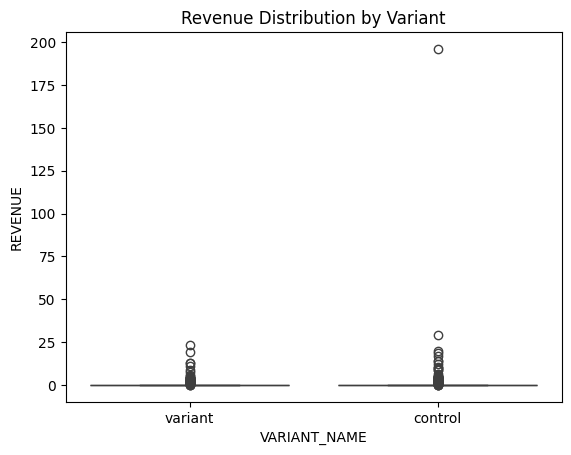

In [48]:
# TODO : Check how the data is distributed using a box plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='VARIANT_NAME', y='REVENUE', data=df_filtered)
plt.title('Revenue Distribution by Variant')
plt.show()

# **We will use another graph to see if we can see better. The issue is that most of the values are close to cero and there is only one value in control that is close to 200**

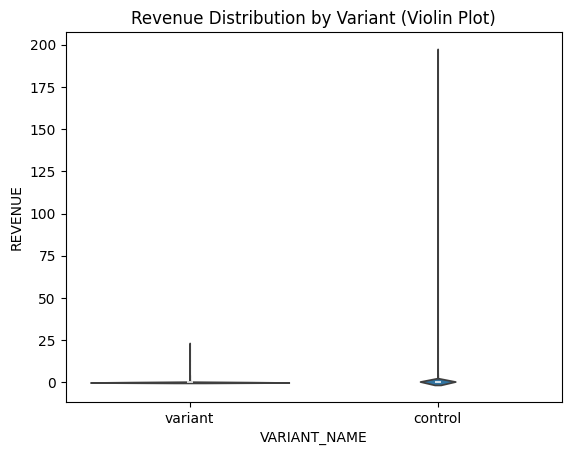

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(x='VARIANT_NAME', y='REVENUE', data=df_filtered)
plt.title('Revenue Distribution by Variant (Violin Plot)')
plt.show()

It can be seen that there is a strong outlier in the data - we will find it by sorting these revenue values in descending order

In [50]:
# TODO : Sort these revenue values in descending order
revenue_sorted = df_filtered.sort_values(by='REVENUE', ascending=False)
print(revenue_sorted)

      USER_ID VARIANT_NAME  REVENUE
1437     3342      control   196.01
8168     2166      control    29.32
2482     7356      variant    23.04
6412     1053      control    20.07
5217     3684      variant    19.47
...       ...          ...      ...
3400     9003      variant     0.00
3401     9902      variant     0.00
3403     4863      control     0.00
3404     1807      control     0.00
3438     4636      control     0.00

[6070 rows x 3 columns]


# **We can see clearly now the atypical values as we saw in the graph before (the 196.01). We see different users that participated in the experiment, to which group they were asignated (control or variant), control represent de actual o standard version and variant represent the modification that is being tested. And Revenue represents the amount of money generated by user during the period of the experiment. Meaning if 0, they didnt buy.**

In [51]:
# TODO : See if user 3342 had other events with a strong outlier
user_3342_events = df_filtered[df_filtered['USER_ID'] == 3342]
print(user_3342_events)

      USER_ID VARIANT_NAME  REVENUE
1437     3342      control   196.01


We see that there is only one outlier - in conditions of limited information, we will remove this entry and look at the distribution of data again

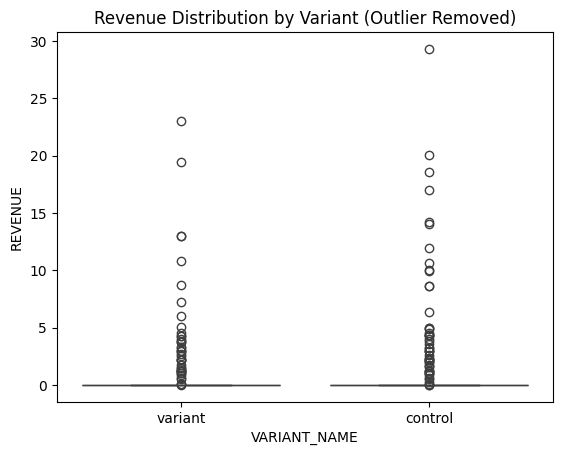

In [52]:
# TODO : We see that there is only one outlier - in conditions of limited information, remove this entry and visualize the distribution of data again.
df_filtered = df_filtered[df_filtered['USER_ID'] != 3342]

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='VARIANT_NAME', y='REVENUE', data=df_filtered)
plt.title('Revenue Distribution by Variant (Outlier Removed)')
plt.show()


What can you say about the users and their purchases ?

# **The majority of users have a revenue of 0. This indicates that most users did not make any purchases during the observed period. Both "control" and "variant" groups have users with zero revenue. This suggests that the lack of purchases is not isolated to one specific group.**

In [53]:
# TODO : Check if there are users who have records with zero and positive revenue
user_revenue_status = df_filtered.groupby('USER_ID')['REVENUE'].agg(lambda x: (x > 0).any() and (x == 0).any())
users_with_mixed_revenue = user_revenue_status[user_revenue_status]

if not users_with_mixed_revenue.empty:
    print("Users with records of both zero and positive revenue:")
    print(users_with_mixed_revenue)
else:
    print("No users have records with both zero and positive revenue.")

Users with records of both zero and positive revenue:
USER_ID
124     True
169     True
282     True
443     True
487     True
708     True
868     True
1035    True
1053    True
1339    True
1883    True
1939    True
2166    True
2181    True
3326    True
3331    True
3699    True
3797    True
4113    True
4858    True
4918    True
5134    True
5597    True
5900    True
6207    True
6271    True
6429    True
7613    True
7930    True
8020    True
8536    True
8583    True
8886    True
8920    True
8927    True
9766    True
9928    True
Name: REVENUE, dtype: bool


# **We can verify this from our dataset, for example user 124 has one revenue of 1.25, and two revenues of 0. These users have shown a mix of behavior: they have had sessions or interactions where they didn't make a purchase (revenue = 0) and sessions or interactions where they did make a purchase (revenue > 0).**

Can a user have records with both zero and positive revenue ?

Let's make the assumption that the records are user visits to the service, and the experimental unit is users.


In [54]:
# TODO : Group the data for each user and sum the revenue for each to get one record per user
df_user_revenue = df_filtered.groupby(['USER_ID', 'VARIANT_NAME'])['REVENUE'].sum().reset_index()
print(df_user_revenue)

      USER_ID VARIANT_NAME  REVENUE
0           2      control      0.0
1           4      variant      0.0
2           5      variant      0.0
3           6      variant      0.0
4           9      variant      0.0
...       ...          ...      ...
4777     9990      variant      0.0
4778     9992      control      0.0
4779     9993      control      0.0
4780     9995      variant      0.0
4781     9998      control      0.0

[4782 rows x 3 columns]


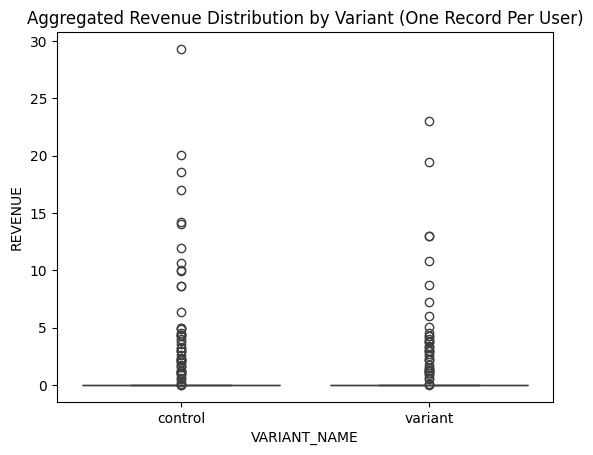

In [55]:
# TODO : Visualize the resulting distribution of the data again.
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='VARIANT_NAME', y='REVENUE', data=df_user_revenue)
plt.title('Aggregated Revenue Distribution by Variant (One Record Per User)')
plt.show()

It should be noted that during the transformation, the quantiles in the test group increased

It can be seen that in the test group, almost all quantile statistics, except for the minimum, are at a slightly lower level.

Let's look at various statistics in the context of AB test groups for all users

In [56]:
# TODO : get metrics by groups
group_metrics = df_user_revenue.groupby('VARIANT_NAME')['REVENUE'].agg(['sum', 'mean', 'median', 'count', 'min', 'max', 'std'])


# TODO : create two additional metrics to see relative changes
group_metrics['revenue_per_user'] = group_metrics['sum'] / group_metrics['count']
group_metrics['revenue_per_paying_user'] = df_user_revenue[df_user_revenue['REVENUE'] > 0].groupby('VARIANT_NAME')['REVENUE'].mean()

# TODO : add them to the rest of the metrics in a separate group
print(group_metrics)


                 sum      mean  median  count  min    max       std  \
VARIANT_NAME                                                          
control       274.55  0.114923     0.0   2389  0.0  29.32  1.162495   
variant       179.32  0.074935     0.0   2393  0.0  23.04  0.858207   

              revenue_per_user  revenue_per_paying_user  
VARIANT_NAME                                             
control               0.114923                 5.180189  
variant               0.074935                 4.269524  


# **We see in sum the total revenue per group. Mean is the average revenue per user in each group. Median is the central value in each group. Count is the number of users, min is the minimum revenue, std is the dispersion of data, renenue per user is the average revenue per user, and revenue per pating user is the revenue per users that buy something, meaning the revenue of users which revenue is more than 0.**

# **Most users made no purchases, but those who did spent more in the control group. This suggests the variant had no positive impact on revenue. Further statistical testing is needed to confirm significance.**

What can you see in the test group about the total amount of revenue, the average check per user, and the number of orders per user slightly increased ?

Let's also see how paying users behave :

In [57]:
# TODO : get metrics by groups
paying_user_metrics = df_user_revenue[df_user_revenue['REVENUE'] > 0].groupby('VARIANT_NAME')['REVENUE'].agg(['sum', 'mean', 'median', 'count', 'min', 'max', 'std'])


# TODO : create two additional metrics to see relative changes
paying_user_metrics['revenue_per_user'] = paying_user_metrics['sum'] / paying_user_metrics['count']


# TODO : add them to the rest of the metrics in a separate group
print(paying_user_metrics)


                 sum      mean  median  count   min    max       std  \
VARIANT_NAME                                                           
control       274.55  5.180189    2.99     53  0.02  29.32  5.942771   
variant       179.32  4.269524    2.97     42  0.02  23.04  4.962253   

              revenue_per_user  
VARIANT_NAME                    
control               5.180189  
variant               4.269524  


# **Paying users in the "control" group generated a total of 274.55. Paying users in the "variant" group generated a total of 179.32. The "control" group generated more total revenue from paying users. Paying users in the "control" group spent more on average. The median revenue was similar in both groups (around 2.98), this indicates that the "typical" paying user spent a similar amount in both groups. There were 53 paying users in the "control" group and 42 in the "variant" group.  The minimum revenue was similar (0.02) in both groups, while the maximum was higher in the control group, indicating also more variabilty in the control group. Even when focusing only on paying users, the "control" group still outperformed the "variant" group.**

Let's look at the distributions of all and only paying users

<ipython-input-58-6823f3e6b917>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[df['VARIANT_NAME'] == 'control', 'REVENUE'], ax = axes[0], label='control')
<ipython-input-58-6823f3e6b917>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[df['VARIANT_NAME'] == 'variant', 'REVENUE'],

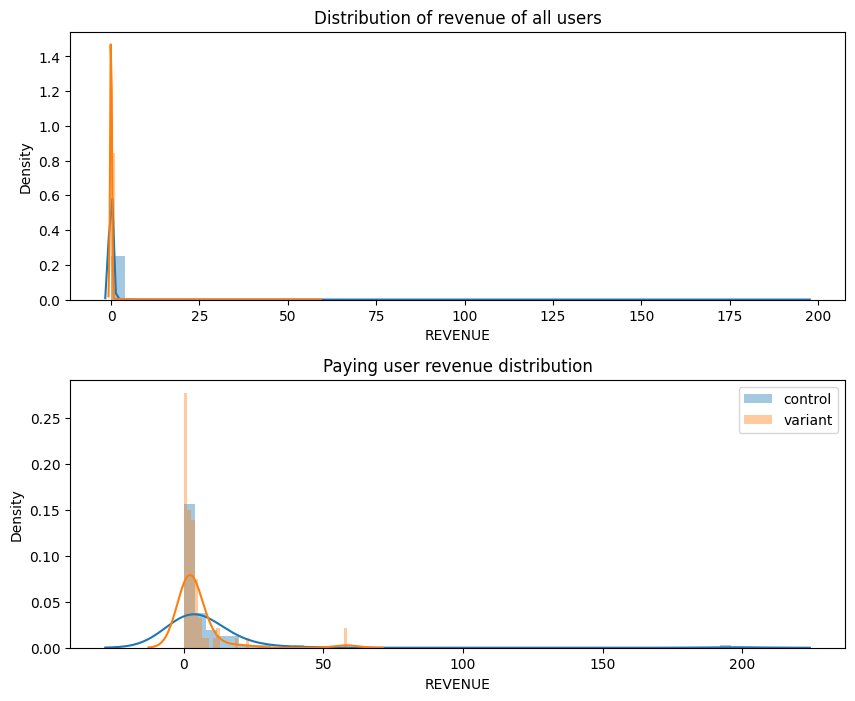

In [58]:
f, axes = plt.subplots(2, figsize=(10,8))
# build graphs of distributions of all users
sns.distplot(df.loc[df['VARIANT_NAME'] == 'control', 'REVENUE'], ax = axes[0], label='control')
sns.distplot(df.loc[df['VARIANT_NAME'] == 'variant', 'REVENUE'], ax = axes[0], label='variant')
axes[0].set_title('Distribution of revenue of all users')

# build graphs of distributions of paying users
sns.distplot(df.loc[(df['VARIANT_NAME'] == 'control') & (df['REVENUE'] > 0), 'REVENUE'], ax = axes[1], label='control' )
sns.distplot(df.loc[(df['VARIANT_NAME'] == 'variant') & (df['REVENUE'] > 0), 'REVENUE'], ax = axes[1], label='variant' )
axes[1].set_title('Paying user revenue distribution')
plt.legend()
plt.subplots_adjust(hspace = 0.3)

# **Here we see again that when we check all together they are all very close to 0. When we check only users that purchased we see more variability, and we see that the control group has more outliers, the tails are longer than the variant group**

### Statistical Analysis <a name="Statistical"/>

#### Checking if the distribution is normal

Based on their previous graph, we see that the data is not normally distributed.

In [59]:
# TODO : Use the Shapiro-Wilk criterion to confirm it

# Test for control group (all users)
control_revenue_all = df_filtered[df_filtered['VARIANT_NAME'] == 'control']['REVENUE']
stat_control_all, p_control_all = shapiro(control_revenue_all)
print(f"Shapiro-Wilk test for control (all users): statistic={stat_control_all}, p-value={p_control_all}")

# Test for variant group (all users)
variant_revenue_all = df_filtered[df_filtered['VARIANT_NAME'] == 'variant']['REVENUE']
stat_variant_all, p_variant_all = shapiro(variant_revenue_all)
print(f"Shapiro-Wilk test for variant (all users): statistic={stat_variant_all}, p-value={p_variant_all}")

# Test for control group (paying users)
control_revenue_paying = df_filtered[(df_filtered['VARIANT_NAME'] == 'control') & (df_filtered['REVENUE'] > 0)]['REVENUE']
stat_control_paying, p_control_paying = shapiro(control_revenue_paying)
print(f"Shapiro-Wilk test for control (paying users): statistic={stat_control_paying}, p-value={p_control_paying}")

# Test for variant group (paying users)
variant_revenue_paying = df_filtered[(df_filtered['VARIANT_NAME'] == 'variant') & (df_filtered['REVENUE'] > 0)]['REVENUE']
stat_variant_paying, p_variant_paying = shapiro(variant_revenue_paying)
print(f"Shapiro-Wilk test for variant (paying users): statistic={stat_variant_paying}, p-value={p_variant_paying}")

Shapiro-Wilk test for control (all users): statistic=0.062157467035860225, p-value=2.083866443535456e-81
Shapiro-Wilk test for variant (all users): statistic=0.051010585813946796, p-value=8.125449426822169e-82
Shapiro-Wilk test for control (paying users): statistic=0.7512773147130261, p-value=4.129931913160037e-08
Shapiro-Wilk test for variant (paying users): statistic=0.7053309591807875, p-value=5.565176147653891e-08


# **In all four cases, the p-values are significantly less than 0.05 (the standard significance level). This means we reject the null hypothesis of normality in all instances. We can confidently conclude that the revenue data for both groups (all users and paying users) is not normally distributed.**

Is the null hypothesis about the normal distribution of the data rejected ?

# **Yes, the null hypothesis about the normal distribution of the data is rejected. As we saw from the Shapiro-Wilk test results, the p-values were extremely small (much less than 0.05) for both the control and variant groups, and for both all users and paying users. This means that there is strong evidence to suggest that the revenue data is not normally distributed.**

#### Mann-Whitney test

Let's check the value of the statistics of the Mann-Whitney test. Some sources

---

have a limitation of applicability in case of duplicate data. There are a lot of repetitions in our sample, and especially a lot of zero values, so in this case we need to be careful about this criterion.

In [60]:
(df['REVENUE'] == 0).value_counts()

,count
REVENUE,
True,9848
False,152


In [61]:
# TODO : Check on the data of all users the value of the statistics of the Mann-Whitney test

from scipy.stats import mannwhitneyu
control_revenue_all = df_filtered[df_filtered['VARIANT_NAME'] == 'control']['REVENUE']
variant_revenue_all = df_filtered[df_filtered['VARIANT_NAME'] == 'variant']['REVENUE']

stat_all, p_all = mannwhitneyu(control_revenue_all, variant_revenue_all)
print(f"Mann-Whitney U test for all users: statistic={stat_all}, p-value={p_all}")

Mann-Whitney U test for all users: statistic=4619788.0, p-value=0.2859842308619548


In [62]:
# TODO : Check on the data of only the users that pay, the value of the statistics of the Mann-Whitney test
control_revenue_paying = df_filtered[(df_filtered['VARIANT_NAME'] == 'control') & (df_filtered['REVENUE'] > 0)]['REVENUE']
variant_revenue_paying = df_filtered[(df_filtered['VARIANT_NAME'] == 'variant') & (df_filtered['REVENUE'] > 0)]['REVENUE']

stat_paying, p_paying = mannwhitneyu(control_revenue_paying, variant_revenue_paying)
print(f"Mann-Whitney U test for paying users: statistic={stat_paying}, p-value={p_paying}")


Mann-Whitney U test for paying users: statistic=1249.0, p-value=0.4218148352342157


# **P-values: In both cases (all users and paying users), the p-values are significantly greater than 0.05. This means we fail to reject the null hypothesis. In conclusion there is not enough statistical evidence to conclude that there is a significant difference in revenue between the control and variant groups, whether we consider all users or only paying users.**

# **Even though the descriptive statistics showed some differences in revenue between the groups, the Mann-Whitney U test indicates that these differences are not statistically significant.**

#### Bootstrap

In order to get more complete information about the differences between the average values of the ab test groups, we will use bootstap.

Let's create a function to get back samples and get a confidence interval, and then look at the sample statistics

In [63]:
def get_bootstrap_samples(data, n_samples=1000):
    indices = np.random.randint(0, len(data), (n_samples, len(data)))
    samples = data[indices]
    return samples

def stat_intervals(stat, alpha=0.05):
    boundaries = np.percentile(stat, [100 * alpha / 2., 100 * (1 - alpha / 2.)])
    return boundaries

In [64]:
# TODO : Generate samples for all users
control_revenue_all = df_filtered[df_filtered['VARIANT_NAME'] == 'control']['REVENUE'].values
variant_revenue_all = df_filtered[df_filtered['VARIANT_NAME'] == 'variant']['REVENUE'].values

control_all = get_bootstrap_samples(control_revenue_all)
variant_all = get_bootstrap_samples(variant_revenue_all)

In [65]:
# TODO : Generate samples for only paying users
control_revenue_paying = df_filtered[(df_filtered['VARIANT_NAME'] == 'control') & (df_filtered['REVENUE'] > 0)]['REVENUE'].values
variant_revenue_paying = df_filtered[(df_filtered['VARIANT_NAME'] == 'variant') & (df_filtered['REVENUE'] > 0)]['REVENUE'].values

control_paid = get_bootstrap_samples(control_revenue_paying)
variant_paid = get_bootstrap_samples(variant_revenue_paying)

Let's look at the distribution of means in the ab test groups

<ipython-input-66-fbc058244eab>:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(np.mean(control_all, axis=1), shade=True, label='control')
<ipython-input-66-fbc058244eab>:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(np.mean(variant_all, axis=1), shade=True, label='variant')


Text(0.5, 1.0, 'Sample mean distribution for all users')

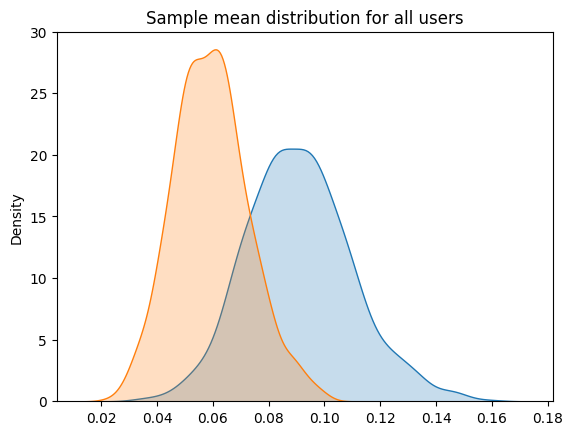

In [66]:
f, ax = plt.subplots()
# plt.figure(figsize=(20,5))
sns.kdeplot(np.mean(control_all, axis=1), shade=True, label='control')
sns.kdeplot(np.mean(variant_all, axis=1), shade=True, label='variant')
plt.title('Sample mean distribution for all users')

<ipython-input-67-fefa5149434d>:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(np.mean(control_paid, axis=1), shade=True, label='control')
<ipython-input-67-fefa5149434d>:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(np.mean(variant_paid, axis=1), shade=True, label='variant')


Text(0.5, 1.0, 'Sample mean distribution for paying users')

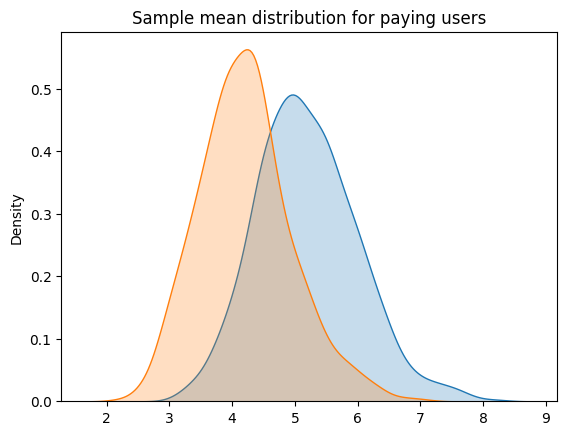

In [67]:
f, ax = plt.subplots()
# plt.figure(figsize=(20,5))
sns.kdeplot(np.mean(control_paid, axis=1), shade=True, label='control')
sns.kdeplot(np.mean(variant_paid, axis=1), shade=True, label='variant')
plt.title('Sample mean distribution for paying users')

# **""This reinforces what we have seen before: a ton of zero revenue values, meaning most users aren't buying anything. Both the control and variant groups are showing this zero-revenue trend, so it's not a group-specific issue. With so few purchases, it's going to be tough to see a real difference between the control and variant. Plus, that outlier's going to mess with our averages if we're not careful. Basically, it is confirming our low conversion rate problem and the need to handle that outlier before we can draw any solid conclusions about the A/B test.""**

# **The "all users" plot shows the average revenue across everyone, while the "paying users" plot shows the average revenue only for those who made purchases. Thats why the all users we see a lot of people who spend mostly 0.**

Do you see any difference ? What about the confidence intervals ? Conclude.

Let's evaluate the difference between the groups: look at the distribution of the mean difference and build confidence intervals for it. To do this, we will create a function for visualization

Let's build a graph of the distribution of the difference in the means and get a confidence interval

For all users

<ipython-input-70-6b10229ea365>:26: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(diff_means, shade=True, label='Difference in Means')


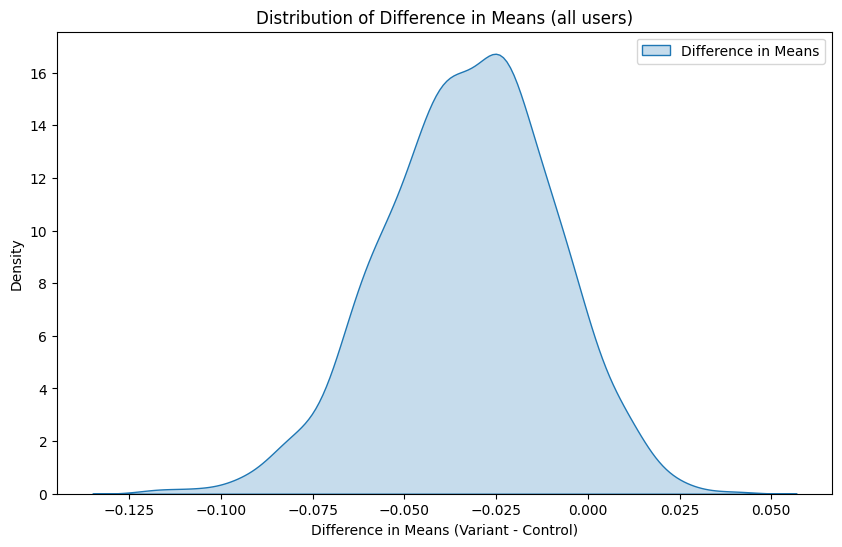

Confidence Interval (95%) for all users: [-0.08012296  0.01066901]


<ipython-input-70-6b10229ea365>:26: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(diff_means, shade=True, label='Difference in Means')


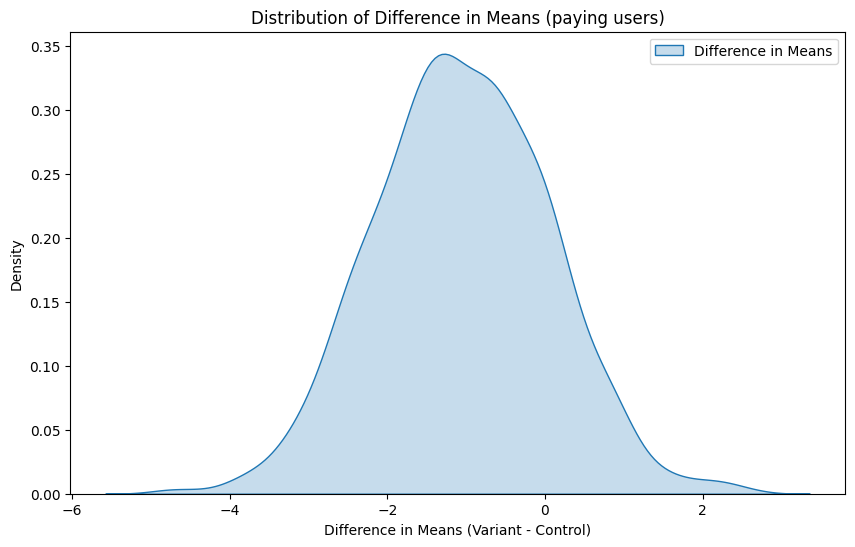

Confidence Interval (95%) for paying users: [-3.14953477  1.031767  ]


In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_filtered is your DataFrame after cleaning and filtering

# Function to generate bootstrap samples
def get_bootstrap_samples(data, n_samples=1000):
    indices = np.random.randint(0, len(data), (n_samples, len(data)))
    samples = data[indices]
    return samples

# Function to calculate confidence intervals
def stat_intervals(stat, alpha=0.05):
    boundaries = np.percentile(stat, [100 * alpha / 2., 100 * (1 - alpha / 2.)])
    return boundaries

# Function to plot distribution and calculate confidence interval
def plot_distribution_and_stat_intervals(variant_data, control_data, title=''):
    variant_means = np.mean(variant_data, axis=1)
    control_means = np.mean(control_data, axis=1)
    diff_means = variant_means - control_means

    plt.figure(figsize=(10, 6))
    sns.kdeplot(diff_means, shade=True, label='Difference in Means')
    plt.title(f'Distribution of Difference in Means ({title})')
    plt.xlabel('Difference in Means (Variant - Control)')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

    ci = stat_intervals(diff_means)
    print(f"Confidence Interval (95%) for {title}: {ci}")

# --- Calculate Confidence Intervals ---

# Generate bootstrap samples for all users
control_revenue_all = df_filtered[df_filtered['VARIANT_NAME'] == 'control']['REVENUE'].values
variant_revenue_all = df_filtered[df_filtered['VARIANT_NAME'] == 'variant']['REVENUE'].values

control_all = get_bootstrap_samples(control_revenue_all)
variant_all = get_bootstrap_samples(variant_revenue_all)

# Generate bootstrap samples for paying users
control_revenue_paying = df_filtered[(df_filtered['VARIANT_NAME'] == 'control') & (df_filtered['REVENUE'] > 0)]['REVENUE'].values
variant_revenue_paying = df_filtered[(df_filtered['VARIANT_NAME'] == 'variant') & (df_filtered['REVENUE'] > 0)]['REVENUE'].values

control_paid = get_bootstrap_samples(control_revenue_paying)
variant_paid = get_bootstrap_samples(variant_revenue_paying)

# Plot and calculate confidence intervals for all users
plot_distribution_and_stat_intervals(variant_all, control_all, title='all users')

# Plot and calculate confidence intervals for paying users
plot_distribution_and_stat_intervals(variant_paid, control_paid, title='paying users')

What can you observe ? Conclude about the statistical change in average revenue between A/B test groups.


# **Both confidence intervals include 0, indicating that there is no statistically significant difference in revenue between the control and variant groups, whether considering all users or only paying users. This data, combined with the previous information, means that the variant group, did not improve the revenue.**